In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from utility import *
from tools import *
from maps import *
from identify import *
from scipy.stats import linregress
from scipy.ndimage import maximum_filter, binary_dilation
from scipy.spatial.distance import cdist

In [2]:
# Load the Data's directory.
datadir = 'C:/Users/txu245/Desktop/26-03-03/04_01_03.zda'

# Load the Tool Packages.
dataLoader = DataLoader(datadir)
tools = Tools()
maps = Maps()
identify = Identify()

In [3]:
# Parameters setting up.
index = np.linspace(0, 499.5, 1000)
basePt = 190
skipPt = 60
startPt = 190
numPt = 150

# Data Preprocessing.
Data = dataLoader.get_data()
Data = tools.Polynomial(startPt=basePt, numPt=skipPt, Data=Data)
Rli = dataLoader.get_rli()
Data = tools.Rli_Division(Rli=Rli, Data=Data)
Data = tools.T_filter(Data=Data)
Data = tools.S_filter(sigma=1, Data=Data)
Data_ave = np.mean(Data, axis=0)

# SNR Map. (Without Normalization)
snr_map = maps.SNR_Map(startPt=startPt, numPt=numPt, Data=Data)

# Rli Map.
rli_high = np.array(Rli['rli_high'])
rli_low = np.array(Rli['rli_low'])

rli = ((rli_high - rli_low) / 3276.8)
bad = np.where(rli==0)
for coor in bad:
    rli[coor] = -1
rli = rli.reshape(80, 80)

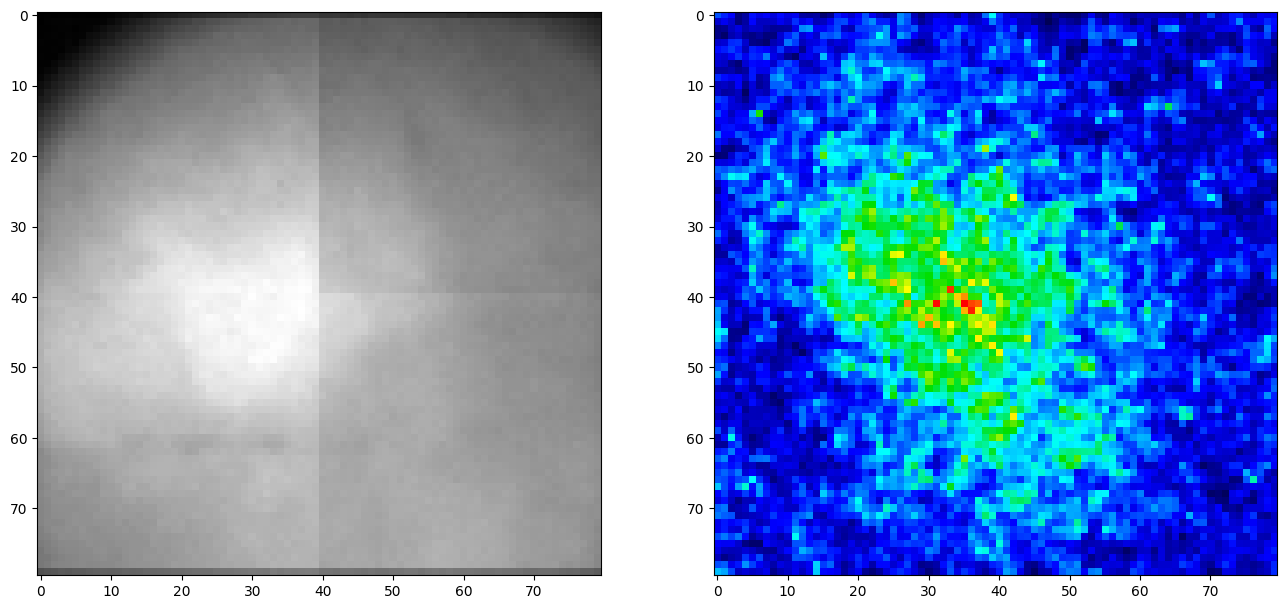

In [4]:
plt.subplots(1, 2, figsize=(16, 8))

ax1 = plt.subplot(1, 2, 1)
ax1.imshow(rli, cmap='gray')

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=maps.colorbar())

plt.show()

In [5]:
candidates = identify.candidates(Data_ave=Data_ave, cutoff=90, startPt=startPt, numPt=numPt)
selected, shapes = identify.select_non_overlap(candidates=candidates, snr_map=snr_map)
identified_map = np.zeros_like(snr_map, dtype=int)

for coor in selected:
    r, c = coor
    identified_map[r][c] = 1

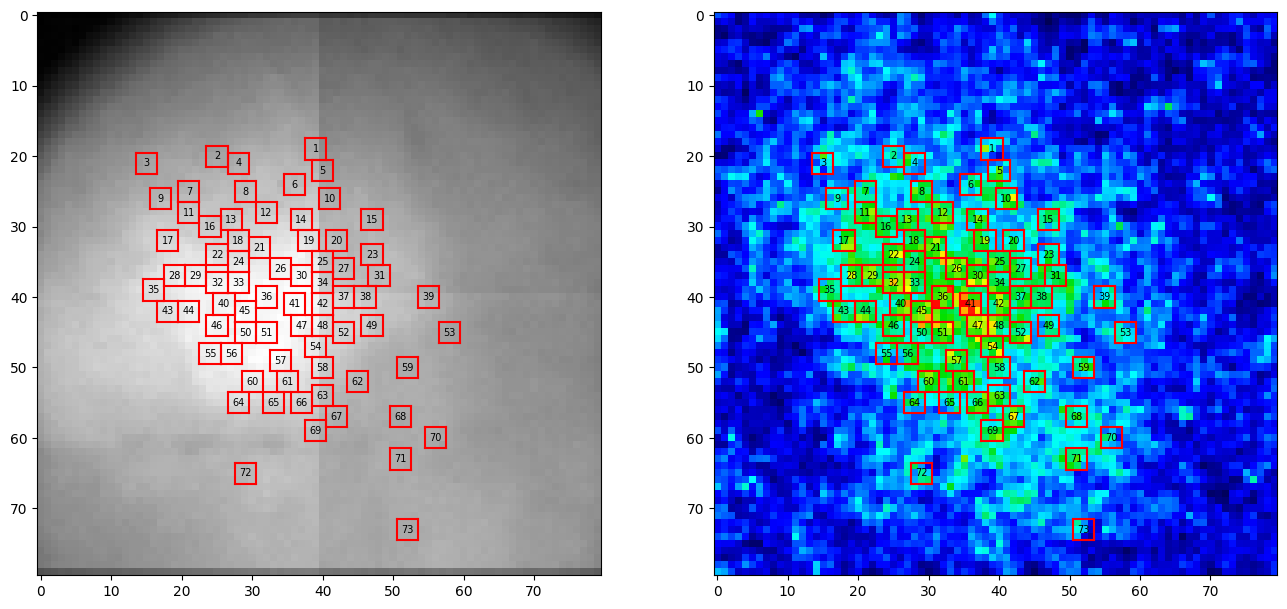

In [6]:
color = 'red'
linewidth = 1.5
index = np.transpose(np.where(identified_map==1), (1, 0))

plt.subplots(1, 2, figsize=(16,8))

ax1 = plt.subplot(1, 2, 1)
ax1.imshow(rli, cmap='gray')

for i, coor in enumerate(index):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax1.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax1.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax1.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax1.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

ax2 = plt.subplot(1, 2, 2)
ax2.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=maps.colorbar())

for i, coor in enumerate(index):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax2.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax2.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax2.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax2.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

plt.show()

Neuron 1 and Neuron 10 are correlated with a positive slope, and the P-Value is: 0.025964 , distance is: 43.68065933568311 um.
Neuron 1 and Neuron 21 are correlated with a positive slope, and the P-Value is: 3.8e-05 , distance is: 96.74709297958259 um.
Neuron 3 and Neuron 24 are correlated with a positive slope, and the P-Value is: 0.017141 , distance is: 114.6298390472568 um.
Neuron 3 and Neuron 32 are correlated with a positive slope, and the P-Value is: 0.01912 , distance is: 118.33849753989612 um.
Neuron 4 and Neuron 66 are correlated with a positive slope, and the P-Value is: 0.042372 , distance is: 211.02606474082768 um.
Neuron 5 and Neuron 59 are correlated with a positive slope, and the P-Value is: 0.026255 , distance is: 182.7785545407338 um.
Neuron 6 and Neuron 42 are correlated with a positive slope, and the P-Value is: 0.02178 , distance is: 104.78549517943787 um.
Neuron 7 and Neuron 49 are correlated with a positive slope, and the P-Value is: 0.047635 , distance is: 193.21

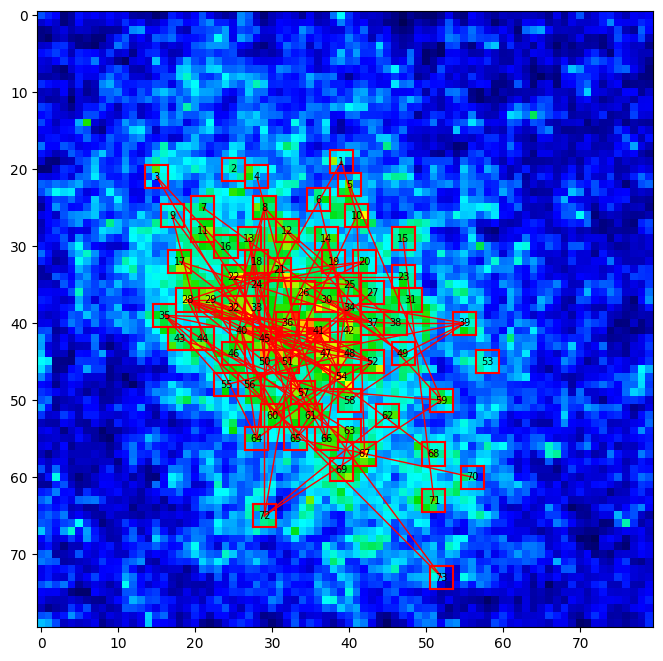

95 pairs are correlated.
Totally 2628 pairs.


In [7]:
num = len(index)
trial = Data.shape[0]
latency = np.zeros((num, trial))
connection = np.zeros(num, dtype=int)
count = 0

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=maps.colorbar())

for i, coor in enumerate(index):

    #  Coordinates for columns and rows.   
    c = coor[0]
    r = coor[1]

    # Pixel boundaries.
    left   = c - 1.5
    right  = c + 1.5
    top    = r - 1.5
    bottom = r + 1.5

    # Draw square contour.
    ax.plot([top, top], [left, right], color=color, linewidth=linewidth)
    ax.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
    ax.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
    ax.plot([top, bottom], [right, right], color=color, linewidth=linewidth)

    # Label index.
    ax.annotate(str(i+1), xy=(r, c), ha='center', va='center', fontsize=7, color='black')

for i in range(num):
    for j in range(trial):

        Trace = np.mean(Data[j, index[i][0]-1:index[i][0]+2, index[i][1]-1:index[i][1]+2, :], axis=(0, 1))
        latency[i][j] = maps.Half_Amp_Latency(Trace=Trace, startPt=startPt, numPt=numPt)

for i in range(num-1):
    for j in range(i+1, num):
        
        dist = np.sqrt((index[i][0] - index[j][0])**2 + (index[i][1] - index[j][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[j])
        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', i+1, 'and Neuron', j+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index[i]
            loc_2 = index[j]
            connection[i] = connection[i] + 1
            connection[j] = connection[j] + 1
            ax.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

plt.show()

print(count, 'pairs are correlated.')
print('Totally', int(num*(num-1)/2), 'pairs.')

Neuron 33 and Neuron 12 are correlated with a positive slope, and the P-Value is: 0.037654 , distance is: 64.62197768561404 um.
Neuron 33 and Neuron 40 are correlated with a positive slope, and the P-Value is: 0.033973 , distance is: 21.633307652783934 um.


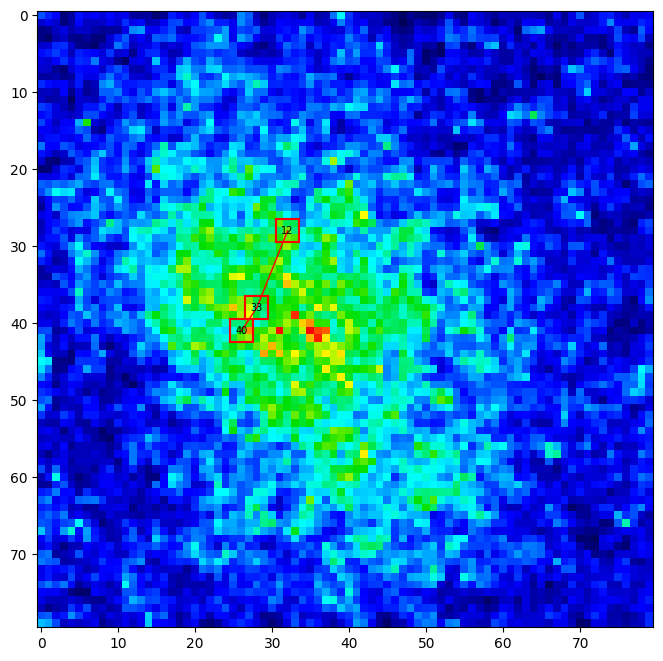

In [8]:
neuro_label = 33

fig, ax = plt.subplots(figsize=(8,8))
ax.imshow(snr_map / np.max(snr_map), vmin=0, vmax=1, cmap=maps.colorbar())
top = index[neuro_label-1][1] - 1.5
bottom = index[neuro_label-1][1] + 1.5
left = index[neuro_label-1][0] - 1.5
right = index[neuro_label-1][0] + 1.5

ax.plot([top, top], [left, right], color=color, linewidth=linewidth)
ax.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
ax.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
ax.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
ax.annotate(str(neuro_label), xy=(index[neuro_label-1][1], index[neuro_label-1][0]), ha='center', va='center', fontsize=7, color='black')

for i in range(num):

    if i == neuro_label - 1:
        continue
    else:
        dist = np.sqrt((index[i][0] - index[neuro_label-1][0])**2 + (index[i][1] - index[neuro_label-1][1])**2) * 6
        Slope, _, _, pValue, _ = linregress(latency[i], latency[neuro_label-1])

        if pValue <=0.05 and Slope > 0:
            count = count + 1
            print('Neuron', neuro_label, 'and Neuron', i+1, 'are correlated with a positive slope, and the P-Value is:', np.round(pValue, 6), ', distance is:', dist, 'um.')
            loc_1 = index[i]
            loc_2 = index[neuro_label-1]

            ax.plot([loc_1[1], loc_2[1]], [loc_1[0], loc_2[0]], color='red', linewidth=1)

            top = loc_1[1] - 1.5
            bottom = loc_1[1] + 1.5
            left = loc_1[0] - 1.5
            right = loc_1[0] + 1.5

            ax.plot([top, top], [left, right], color=color, linewidth=linewidth)
            ax.plot([bottom, bottom], [left, right], color=color, linewidth=linewidth)
            ax.plot([top, bottom], [left, left], color=color, linewidth=linewidth)
            ax.plot([top, bottom], [right, right], color=color, linewidth=linewidth)
            ax.annotate(str(i+1), xy=(loc_1[1], loc_1[0]), ha='center', va='center', fontsize=7, color='black')

plt.show()
        

In [9]:
'''
with open('C:/Users/txu245/Desktop/26-03-03/04_01_01_latency.dat', 'a') as f:
    for coor in latency:
        line = '[' + ' '.join(map(str,coor)) + ']'
        f.write(line + '\n')

with open('C:/Users/txu245/Desktop/26-03-03/04_01_01_location.dat', 'a') as f:
    for coor in index:
        line = '[' + ' '.join(map(str,coor)) + ']'
        f.write(line + '\n')

with open('C:/Users/txu245/Desktop/26-03-03/04_01_01_rli.dat', 'a') as f:
    for coor in rli:
        line = '[' + ' '.join(map(str,coor)) + ']'
        f.write(line + '\n')
'''

"\nwith open('C:/Users/txu245/Desktop/26-03-03/04_01_01_latency.dat', 'a') as f:\n    for coor in latency:\n        line = '[' + ' '.join(map(str,coor)) + ']'\n        f.write(line + '\n')\n\nwith open('C:/Users/txu245/Desktop/26-03-03/04_01_01_location.dat', 'a') as f:\n    for coor in index:\n        line = '[' + ' '.join(map(str,coor)) + ']'\n        f.write(line + '\n')\n\nwith open('C:/Users/txu245/Desktop/26-03-03/04_01_01_rli.dat', 'a') as f:\n    for coor in rli:\n        line = '[' + ' '.join(map(str,coor)) + ']'\n        f.write(line + '\n')\n"

In [12]:
index[67]

array([57, 51])

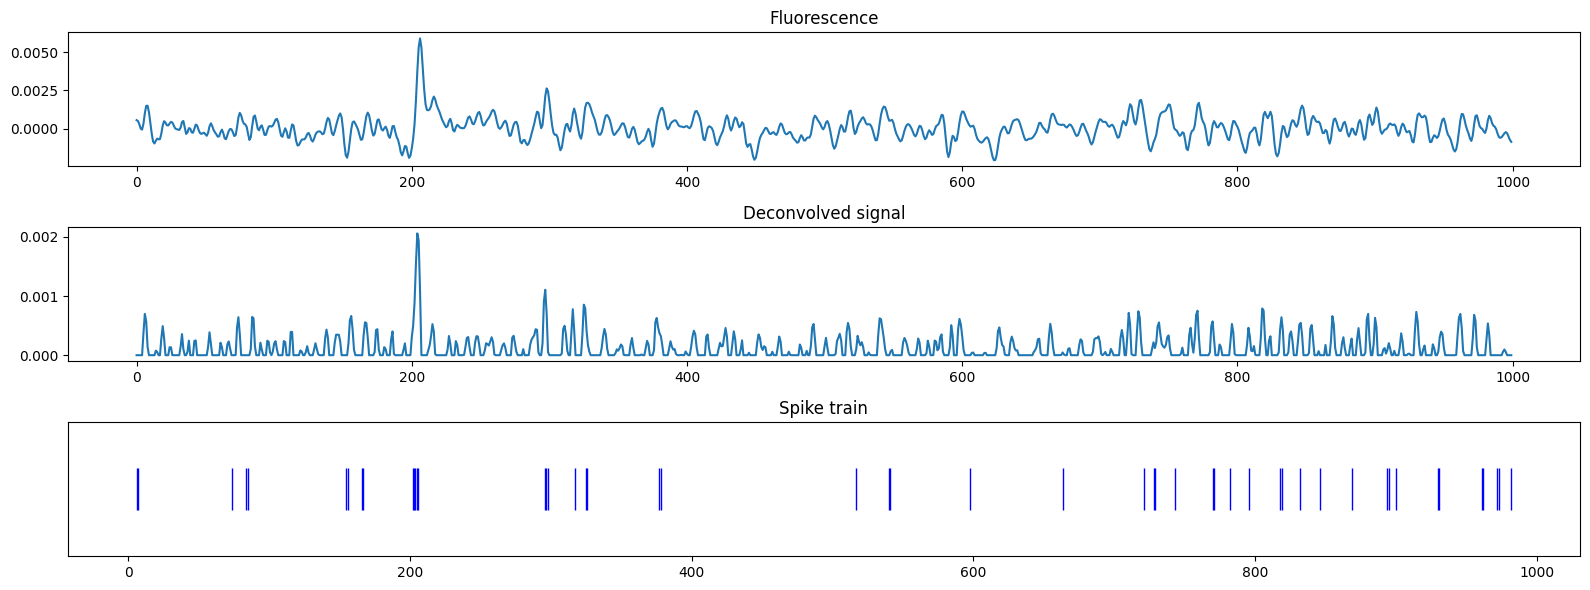

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import detrend

def fluorescence_to_spikes(F, tau=10, dt=1):
    
    # detrend
    F = detrend(F)
    
    # decay factor
    gamma = np.exp(-dt/tau)
    
    # deconvolution
    s = np.zeros_like(F)
    
    for t in range(1, len(F)):
        s[t] = F[t] - gamma * F[t-1]
    
    # enforce non-negative spikes
    s[s < 0] = 0
    
    return s


# --------------------------------
# Example data
# --------------------------------
result = [item for item in candidates if item[0] == index[42][0] and item[1] == index[42][1]]
_, _, _, coordinate = result[0]

fluorescence = []
for i, coor in enumerate(coordinate):
    r = coor[0]
    c = coor[1]

    fluorescence.append(Data_ave[r][c])

fluorescence = np.array(fluorescence)
fluorescence = np.mean(fluorescence, axis=0)

# --------------------------------
# Run deconvolution
# --------------------------------
s = fluorescence_to_spikes(fluorescence, tau=10)

# threshold
threshold = np.percentile(s,95)
spike_train = (s > threshold).astype(int)

# --------------------------------
# Plot
# --------------------------------
plt.figure(figsize=(16,6))

plt.subplot(3,1,1)
plt.plot(fluorescence)
plt.title("Fluorescence")

plt.subplot(3,1,2)
plt.plot(s)
plt.title("Deconvolved signal")

# convert to spike times
spike_times = np.where(spike_train == 1)
plt.subplot(3,1,3)


plt.plot(spike_times, np.ones_like(spike_times), ls='', marker='|', markersize=30, color='blue')
plt.yticks([])
plt.title("Spike train")


plt.tight_layout()
plt.show()